Evaluation:

Epoch 44 - Loss: 0.0531 - Elapsed Time: 16210.1 seconds - Epoch Time: 378.9 seconds

Epoch 45 - Loss: 0.0528 - Elapsed Time: 16587.2 seconds - Epoch Time: 376.4 seconds

Epoch 46 - Loss: 0.0527 - Elapsed Time: 16962.9 seconds - Epoch Time: 374.8 seconds

Epoch 47 - Loss: 0.0523 - Elapsed Time: 17340.2 seconds - Epoch Time: 376.5 seconds

Epoch 48 - Loss: 0.0520 - Elapsed Time: 17716.4 seconds - Epoch Time: 375.3 seconds

Epoch 49 - Loss: 0.0521 - Elapsed Time: 18087.8 seconds - Epoch Time: 370.7 seconds

Epoch 50 - Loss: 0.0517 - Elapsed Time: 18454.1 seconds - Epoch Time: 365.5 seconds

Epoch 51 - Loss: 0.0521 - Elapsed Time: 18819.7 seconds - Epoch Time: 364.8 seconds

Epoch 52 - Loss: 0.0514 - Elapsed Time: 19185.9 seconds - Epoch Time: 365.4 seconds

Epoch 53 - Loss: 0.0511 - Elapsed Time: 19553.0 seconds - Epoch Time: 366.3 seconds

Epoch 54 - Loss: 0.0510 - Elapsed Time: 19922.2 seconds - Epoch Time: 368.4 seconds

Epoch 55 - Loss: 0.0513 - Elapsed Time: 20288.2 seconds - Epoch Time: 365.2 seconds

Epoch 56 - Loss: 0.0506 - Elapsed Time: 20654.6 seconds - Epoch Time: 365.6 seconds

Epoch 57 - Loss: 0.0505 - Elapsed Time: 21020.7 seconds - Epoch Time: 365.3 seconds

Epoch 58 - Loss: 0.0502 - Elapsed Time: 21387.4 seconds - Epoch Time: 365.9 seconds

Epoch 59 - Loss: 0.0501 - Elapsed Time: 21752.6 seconds - Epoch Time: 364.5 seconds

Epoch 60 - Loss: 0.0500 - Elapsed Time: 22131.1 seconds - Epoch Time: 377.7 seconds

Epoch 61 - Loss: 0.0496 - Elapsed Time: 22508.4 seconds - Epoch Time: 376.4 seconds

Epoch 62 - Loss: 0.0497 - Elapsed Time: 22886.1 seconds - Epoch Time: 376.9 seconds

Epoch 63 - Loss: 0.0494 - Elapsed Time: 23263.2 seconds - Epoch Time: 376.2 seconds

Epoch 64 - Loss: 0.0495 - Elapsed Time: 23655.2 seconds - Epoch Time: 391.2 seconds

Epoch 65 - Loss: 0.0493 - Elapsed Time: 24134.0 seconds - Epoch Time: 477.9 seconds

Epoch 66 - Loss: 0.0491 - Elapsed Time: 24696.9 seconds - Epoch Time: 561.6 seconds

Epoch 67 - Loss: 0.0492 - Elapsed Time: 25175.3 seconds - Epoch Time: 477.6 seconds

Epoch 68 - Loss: 0.0486 - Elapsed Time: 25685.0 seconds - Epoch Time: 509.0 seconds


Total Training Time approx. 7 hours
After 40 epochs, the loss is around 5%, what is a good sign.

The Reconstructed Images are very close to the original ones, but still somewhat blurry.

The sample photos were not selected carefully, which affected the quality of the face swap results.

Here are visual results from the training process:

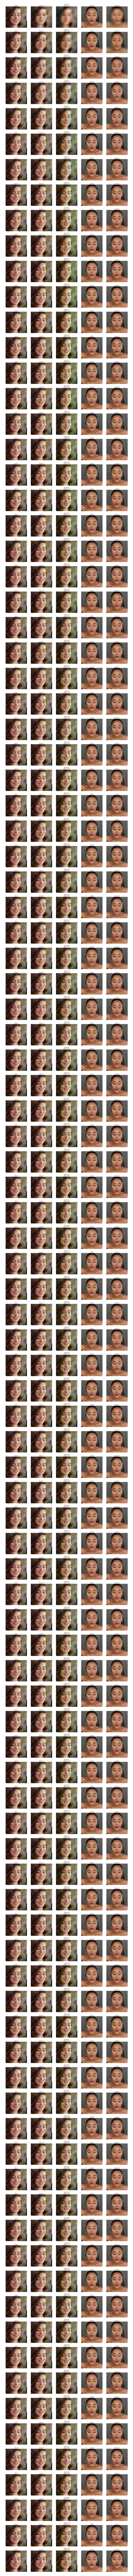

In [28]:
import os
from PIL import Image
import matplotlib.pyplot as plt

path = "../../checkpoints/"

folders = []

for f in os.listdir(path):
    full_path = os.path.join(path, f)

    if os.path.isdir(full_path) and f.isdigit():
        folders.append(f)

folders.sort(key=lambda x: int(x))

images = []

for folder in folders:
    folder_path = os.path.join(path, folder)

    png_files = sorted(
        [f for f in os.listdir(folder_path) if f.lower().endswith(".png")]
    )

    for file in png_files:
        img_path = os.path.join(folder_path, file)
        img = Image.open(img_path)
        images.append(img)

if not images:
    print("No images found.")
    exit()

max_width = 2000
total_height = sum(img.height for img in images)

merged_image = Image.new("RGB", (max_width, total_height))

y_offset = 0
for img in images:
    merged_image.paste(img, (0, y_offset))
    y_offset += img.height

plt.figure(figsize=(40, 80))
plt.imshow(merged_image)
plt.axis("off")
plt.tight_layout()
plt.show()

After training, I can’t see any difference between the original and the swapped version (A -> B), which means the model failed to swap the face.

Now let's try swapping face with the trained model and see the results:

In [2]:
from train import denormalize, Encoder, Decoder
from torchvision import transforms
from PIL import Image
import torch
import matplotlib.pyplot as plt

EPOCH = 1

def to_numpy(tensor):
    return denormalize(tensor.squeeze(0)).clamp(0, 1).permute(1, 2, 0).cpu().numpy()

def swap_faces(sample_a_path, sample_b_path):
    encoder = Encoder().to("cuda")
    decoder_a = Decoder().to("cuda")
    decoder_b = Decoder().to("cuda")

    encoder.load_state_dict(torch.load(f"checkpoints/{EPOCH}/encoder.pth",   map_location="cuda"))
    decoder_a.load_state_dict(torch.load(f"checkpoints/{EPOCH}/decoder_A.pth", map_location="cuda"))
    decoder_b.load_state_dict(torch.load(f"checkpoints/{EPOCH}/decoder_B.pth", map_location="cuda"))

    encoder.eval()
    decoder_a.eval()
    decoder_b.eval()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    img_a = Image.open(sample_a_path).convert('RGB')
    img_b = Image.open(sample_b_path).convert('RGB')

    sample_a = transform(img_a).unsqueeze(0).to("cuda")
    sample_b = transform(img_b).unsqueeze(0).to("cuda")

    with torch.no_grad():
        latent_a = encoder(sample_a)
        latent_b = encoder(sample_b)

        recon_a  = decoder_a(latent_a)
        recon_b  = decoder_b(latent_b)

        swap_ab  = decoder_b(latent_a)
        swap_ba  = decoder_a(latent_b)

    imgs   = [to_numpy(sample_a), to_numpy(recon_a), to_numpy(swap_ab),
              to_numpy(sample_b), to_numpy(recon_b), to_numpy(swap_ba)]
    titles = ["Real A", "Recon A", "Swap A→B",
              "Real B", "Recon B", "Swap B→A"]

    fig, axes = plt.subplots(1, 6, figsize=(24, 4))
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    plt.close()

swap_faces("personA/00002.jpg", "personB/00000.jpg")

TypeError: Decoder.forward() missing 1 required positional argument: 'skips'

Again, I can't see the difference at all

In [4]:
from train import Encoder, Decoder
import os
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

EPOCH = 165

def swap_first_10(folder_path):
    device = "cuda"

    encoder = Encoder().to(device)
    decoder_a = Decoder().to(device)

    encoder.load_state_dict(torch.load(f"checkpoints/{EPOCH}/encoder.pth", map_location=device))
    decoder_a.load_state_dict(torch.load(f"checkpoints/{EPOCH}/decoder_B.pth", map_location=device))

    encoder.eval()
    decoder_a.eval()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5],
                             [0.5, 0.5, 0.5])
    ])

    image_files = sorted(os.listdir(folder_path))[1000:1010]

    originals = []
    fakes = []

    with torch.no_grad():
        for file in image_files:
            path = os.path.join(folder_path, file)

            img = Image.open(path).convert("RGB")
            sample = transform(img).unsqueeze(0).to(device)

            latent, skips = encoder(sample)
            fake = decoder_a(latent, skips)

            originals.append(to_numpy(sample))
            fakes.append(to_numpy(fake))

    fig, axes = plt.subplots(10, 2, figsize=(6, 20))

    for i in range(10):
        axes[i, 0].imshow(originals[i])
        axes[i, 0].axis("off")

        axes[i, 1].imshow(fakes[i])
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close()

swap_first_10("personA")

ValueError: not enough values to unpack (expected 2, got 1)

Let's at least evaluate a learning curve:

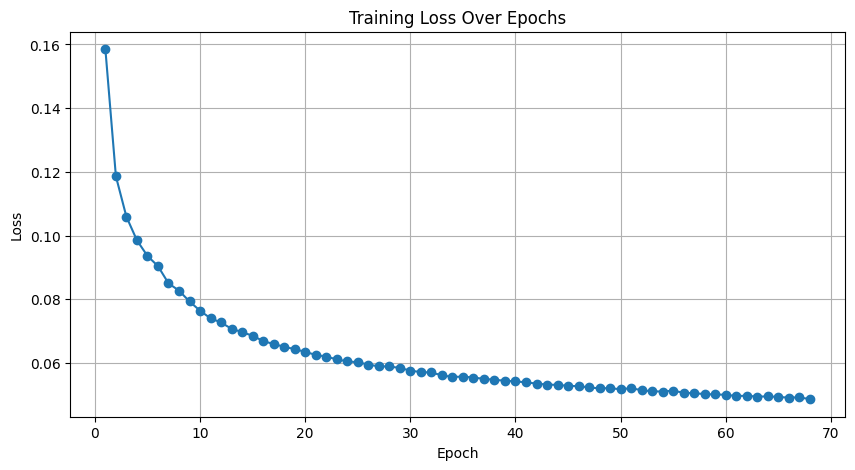

In [13]:
import re
import matplotlib.pyplot as plt

log = """
Epoch 1 - Loss: 0.1585 - Elapsed Time: 322.6 seconds - Epoch Time: 317.8 seconds

Epoch 2 - Loss: 0.1186 - Elapsed Time: 640.2 seconds - Epoch Time: 316.9 seconds

Epoch 3 - Loss: 0.1059 - Elapsed Time: 964.9 seconds - Epoch Time: 324.0 seconds

Epoch 4 - Loss: 0.0985 - Elapsed Time: 1289.3 seconds - Epoch Time: 323.6 seconds

Epoch 5 - Loss: 0.0936 - Elapsed Time: 1613.2 seconds - Epoch Time: 323.2 seconds

Epoch 6 - Loss: 0.0904 - Elapsed Time: 1933.7 seconds - Epoch Time: 319.8 seconds

Epoch 7 - Loss: 0.0850 - Elapsed Time: 2281.6 seconds - Epoch Time: 347.3 seconds

Epoch 8 - Loss: 0.0827 - Elapsed Time: 2728.1 seconds - Epoch Time: 445.6 seconds

Epoch 9 - Loss: 0.0793 - Elapsed Time: 3127.8 seconds - Epoch Time: 398.9 seconds

Epoch 10 - Loss: 0.0764 - Elapsed Time: 3528.3 seconds - Epoch Time: 399.8 seconds

Epoch 11 - Loss: 0.0740 - Elapsed Time: 3908.3 seconds - Epoch Time: 379.2 seconds

Epoch 12 - Loss: 0.0727 - Elapsed Time: 4279.2 seconds - Epoch Time: 370.1 seconds

Epoch 13 - Loss: 0.0707 - Elapsed Time: 4647.6 seconds - Epoch Time: 367.6 seconds

Epoch 14 - Loss: 0.0697 - Elapsed Time: 5016.4 seconds - Epoch Time: 368.0 seconds

Epoch 15 - Loss: 0.0685 - Elapsed Time: 5382.8 seconds - Epoch Time: 365.6 seconds

Epoch 16 - Loss: 0.0669 - Elapsed Time: 5744.8 seconds - Epoch Time: 361.2 seconds

Epoch 17 - Loss: 0.0659 - Elapsed Time: 6107.6 seconds - Epoch Time: 362.0 seconds

Epoch 18 - Loss: 0.0651 - Elapsed Time: 6469.8 seconds - Epoch Time: 361.5 seconds

Epoch 19 - Loss: 0.0643 - Elapsed Time: 6833.3 seconds - Epoch Time: 362.7 seconds

Epoch 20 - Loss: 0.0635 - Elapsed Time: 7229.7 seconds - Epoch Time: 395.6 seconds

Epoch 21 - Loss: 0.0625 - Elapsed Time: 7610.1 seconds - Epoch Time: 379.6 seconds

Epoch 22 - Loss: 0.0620 - Elapsed Time: 7986.2 seconds - Epoch Time: 375.3 seconds

Epoch 23 - Loss: 0.0611 - Elapsed Time: 8362.0 seconds - Epoch Time: 375.0 seconds

Epoch 24 - Loss: 0.0605 - Elapsed Time: 8738.9 seconds - Epoch Time: 376.2 seconds

Epoch 25 - Loss: 0.0602 - Elapsed Time: 9116.4 seconds - Epoch Time: 376.6 seconds

Epoch 26 - Loss: 0.0595 - Elapsed Time: 9489.7 seconds - Epoch Time: 372.6 seconds

Epoch 27 - Loss: 0.0589 - Elapsed Time: 9874.9 seconds - Epoch Time: 384.4 seconds

Epoch 28 - Loss: 0.0589 - Elapsed Time: 10250.8 seconds - Epoch Time: 375.1 seconds

Epoch 29 - Loss: 0.0584 - Elapsed Time: 10631.1 seconds - Epoch Time: 379.5 seconds

Epoch 30 - Loss: 0.0576 - Elapsed Time: 11018.2 seconds - Epoch Time: 386.3 seconds

Epoch 31 - Loss: 0.0571 - Elapsed Time: 11411.6 seconds - Epoch Time: 392.6 seconds

Epoch 32 - Loss: 0.0570 - Elapsed Time: 11787.8 seconds - Epoch Time: 375.4 seconds

Epoch 33 - Loss: 0.0561 - Elapsed Time: 12164.4 seconds - Epoch Time: 375.8 seconds

Epoch 34 - Loss: 0.0556 - Elapsed Time: 12531.9 seconds - Epoch Time: 366.7 seconds

Epoch 35 - Loss: 0.0557 - Elapsed Time: 12898.1 seconds - Epoch Time: 365.4 seconds

Epoch 36 - Loss: 0.0554 - Elapsed Time: 13265.2 seconds - Epoch Time: 366.4 seconds

Epoch 37 - Loss: 0.0550 - Elapsed Time: 13631.6 seconds - Epoch Time: 365.5 seconds

Epoch 38 - Loss: 0.0547 - Elapsed Time: 13998.5 seconds - Epoch Time: 366.1 seconds

Epoch 39 - Loss: 0.0544 - Elapsed Time: 14365.0 seconds - Epoch Time: 365.7 seconds

Epoch 40 - Loss: 0.0542 - Elapsed Time: 14731.7 seconds - Epoch Time: 365.9 seconds

Epoch 41 - Loss: 0.0539 - Elapsed Time: 15098.0 seconds - Epoch Time: 365.5 seconds

Epoch 42 - Loss: 0.0535 - Elapsed Time: 15463.9 seconds - Epoch Time: 365.1 seconds

Epoch 43 - Loss: 0.0532 - Elapsed Time: 15830.3 seconds - Epoch Time: 365.7 seconds

Epoch 44 - Loss: 0.0531 - Elapsed Time: 16210.1 seconds - Epoch Time: 378.9 seconds

Epoch 45 - Loss: 0.0528 - Elapsed Time: 16587.2 seconds - Epoch Time: 376.4 seconds

Epoch 46 - Loss: 0.0527 - Elapsed Time: 16962.9 seconds - Epoch Time: 374.8 seconds

Epoch 47 - Loss: 0.0523 - Elapsed Time: 17340.2 seconds - Epoch Time: 376.5 seconds

Epoch 48 - Loss: 0.0520 - Elapsed Time: 17716.4 seconds - Epoch Time: 375.3 seconds

Epoch 49 - Loss: 0.0521 - Elapsed Time: 18087.8 seconds - Epoch Time: 370.7 seconds

Epoch 50 - Loss: 0.0517 - Elapsed Time: 18454.1 seconds - Epoch Time: 365.5 seconds

Epoch 51 - Loss: 0.0521 - Elapsed Time: 18819.7 seconds - Epoch Time: 364.8 seconds

Epoch 52 - Loss: 0.0514 - Elapsed Time: 19185.9 seconds - Epoch Time: 365.4 seconds

Epoch 53 - Loss: 0.0511 - Elapsed Time: 19553.0 seconds - Epoch Time: 366.3 seconds

Epoch 54 - Loss: 0.0510 - Elapsed Time: 19922.2 seconds - Epoch Time: 368.4 seconds

Epoch 55 - Loss: 0.0513 - Elapsed Time: 20288.2 seconds - Epoch Time: 365.2 seconds

Epoch 56 - Loss: 0.0506 - Elapsed Time: 20654.6 seconds - Epoch Time: 365.6 seconds

Epoch 57 - Loss: 0.0505 - Elapsed Time: 21020.7 seconds - Epoch Time: 365.3 seconds

Epoch 58 - Loss: 0.0502 - Elapsed Time: 21387.4 seconds - Epoch Time: 365.9 seconds

Epoch 59 - Loss: 0.0501 - Elapsed Time: 21752.6 seconds - Epoch Time: 364.5 seconds

Epoch 60 - Loss: 0.0500 - Elapsed Time: 22131.1 seconds - Epoch Time: 377.7 seconds

Epoch 61 - Loss: 0.0496 - Elapsed Time: 22508.4 seconds - Epoch Time: 376.4 seconds

Epoch 62 - Loss: 0.0497 - Elapsed Time: 22886.1 seconds - Epoch Time: 376.9 seconds

Epoch 63 - Loss: 0.0494 - Elapsed Time: 23263.2 seconds - Epoch Time: 376.2 seconds

Epoch 64 - Loss: 0.0495 - Elapsed Time: 23655.2 seconds - Epoch Time: 391.2 seconds

Epoch 65 - Loss: 0.0493 - Elapsed Time: 24134.0 seconds - Epoch Time: 477.9 seconds

Epoch 66 - Loss: 0.0491 - Elapsed Time: 24696.9 seconds - Epoch Time: 561.6 seconds

Epoch 67 - Loss: 0.0492 - Elapsed Time: 25175.3 seconds - Epoch Time: 477.6 seconds

Epoch 68 - Loss: 0.0486 - Elapsed Time: 25685.0 seconds - Epoch Time: 509.0 seconds

"""

epochs = [int(m.group(1)) for m in re.finditer(r"Epoch (\d+) - Loss: ([0-9.]+)", log)]
losses = [float(m.group(2)) for m in re.finditer(r"Epoch (\d+) - Loss: ([0-9.]+)", log)]

plt.figure(figsize=(10,5))
plt.plot(epochs, losses, marker='o', linestyle='-')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)
plt.show()

The decrease is gradual and smooth, so i can say, that the model seems to be learning properly

Conclusion:
The results were not as expected. Instead of successfully swapping faces, the model mostly reconstructs the original image, showing no actual face swap.

Potential Issues:
Model architecture: The current architecture may be too simple, with too few parameters
Loss function: Using a basic L1 loss might be insufficient, potentially causing an uncanny valley effect
Dataset preprocessing: It is possible that the dataset was not properly processed, as I'm still learning

Overall, while the model can reproduce images reasonably well, it fails at the intended task of face swapping
Let's try again with other architecture